In [1]:
import numpy as np
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Load excel dataset
df=pd.read_excel('WOS.xlsx')

In [5]:
df.head()

,Last Material,Description,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,...,Demand 12m,Qty Expedite,Mrp Profile,D-Chain*,Git Sps,Git Km,Item Cat Group,Demand Spike %,New_Buy_LT,Repair_LT
0,452212806671,interface holder filters,0.60,1.14,1.14,1.06,0.57,0.49,0.09,0.06,...,5,0.85,ZMCA,ZS,0.0,0,ZSID,78.57%,35.0,0.0
1,452212896712,FILTER PLATE CU 0.5,1.48,1.45,1.45,1.12,0.93,1.11,1.24,0.84,...,10,0.00,ZMCA,ZS,0.0,0,ZSID,132.56%,45.0,45.0
2,452212896722,FILTER PLATE CU 1.5,3.42,3.37,3.27,2.75,2.63,2.63,1.20,1.56,...,33,0.00,ZMCA,ZS,0.0,0,ZSID,22.95%,105.0,0.0
3,452230035475,EDL TOOL,23.37,24.41,24.96,24.97,31.55,25.48,27.45,27.95,...,399,0.00,ZMTO,23,1.0,1,ZSID,-4.94%,140.0,0.0
4,453560816321,"Dodekaeder Phantom 12/15""",0.24,0.17,0.17,0.12,0.03,0.03,0.00,0.00,...,1,0.00,ZMCA,NaN,0.0,0,ZSID,No Demand,45.0,45.0


In [6]:
print(df.shape)
print(df.isnull().sum())

(41542, 61)
Last Material     0
Description       0
Mar'24            0
Apr'24            0
May'24            0
                 ..
Git Km            0
Item Cat Group    0
Demand Spike %    0
New_Buy_LT        0
Repair_LT         0
Length: 61, dtype: int64


In [7]:
print(df.describe())

             Mar'24        Apr'24        May'24       June'24       July'24  \
count  41542.000000  41542.000000  41542.000000  41542.000000  41542.000000   
mean       2.249316      2.198217      2.193207      2.312254      2.355924   
std       27.195012     21.217995     21.294695     27.629949     32.019927   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.020000      0.010000      0.020000      0.000000      0.000000   
75%        0.590000      0.570000      0.580000      0.570000      0.450000   
max     4147.610000   2327.550000   2301.290000   3515.840000   3516.470000   

             Aug'24        Sep'24        Oct'24        Nov'24        Dec'24  \
count  41542.000000  41542.000000  41542.000000  41542.000000  41542.000000   
mean       2.245255      2.096094      2.112591      2.134559      2.094561   
std       31.842187     29.121370     34.574911    

In [8]:
# Clean Column Names
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.columns

Index(['Last_Material', 'Description', 'Mar'24', 'Apr'24', 'May'24', 'June'24',
       'July'24', 'Aug'24', 'Sep'24', 'Oct'24', 'Nov'24', 'Dec'24', 'Jan'25',
       'Feb'25', 'Mar'25', 'Apr'25', 'May'25', 'June'25', 'Jul'25', 'Aug'25',
       'Sep'25', 'Oct'25', 'Nov'25', 'Dec'25', 'Jan'26', 'Feb'26', 'Mar'26',
       'Apr'26', 'May'26', 'Open_Po_Qty_Nb', 'Open_Po_Qty_Rp', 'Total_Open_Po',
       'Bu', 'Part_Nature', 'Supplier_New_Buy', 'Supplier_Name_New_Buy',
       'Supplier_D', 'Supplier_Name_D', 'Critical_Segment*', 'Mrpc',
       'Purch_Group', 'Sufficient_Po', 'Wos_Summary', 'Oh_U', 'Oh_Inventory',
       'Oh_D', 'Net_Inventory', 'Exact_WOS', 'Open_Bo_Qty', 'Bck_Sm_Qty',
       'Dmd_Last_30_Days', 'Demand_12m', 'Qty_Expedite', 'Mrp_Profile',
       'D-Chain*', 'Git_Sps', 'Git_Km', 'Item_Cat_Group', 'Demand_Spike_%',
       'New_Buy_LT', 'Repair_LT'],
      dtype='str')

In [9]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

Bck_Sm_Qty               41332
Supplier_Name_D          39794
Supplier_D               39650
D-Chain*                 19044
Supplier_Name_New_Buy    14284
                         ...  
Git_Km                       0
Item_Cat_Group               0
Demand_Spike_%               0
New_Buy_LT                   0
Repair_LT                    0
Length: 61, dtype: int64

In [10]:
# Remove duplicate
df.duplicated().sum()
df = df.drop_duplicates()

In [11]:
# Basic Inventory KPIs
df['Total_Incoming_Supply'] = (
    df['Open_Po_Qty_Nb'] +
    df['Open_Po_Qty_Rp']
)

In [12]:
# Projected Inventory
df['Projected_Inventory'] = (
    df['Oh_U'] +
    df['Total_Incoming_Supply']
)

In [13]:
# Inventory Gap
df['Inventory_Gap'] = (
    df['Projected_Inventory'] -
    df['Dmd_Last_30_Days']
)

In [14]:
#Classify Inventory Health

def inventory_status(x):
    if x < 0:
        return 'Shortage'
    elif x <= 2:
        return 'Critical'
    elif x <= 10:
        return 'Healthy'
    else:
        return 'Excess'

df['Inventory_Status'] = df['Inventory_Gap'].apply(inventory_status)

In [15]:
# Explore the Data
df.describe()
df['Inventory_Status'].value_counts()

Inventory_Status
Excess      19064
Healthy     13840
Critical     8421
Shortage      217
Name: count, dtype: int64

In [16]:
df.columns

Index(['Last_Material', 'Description', 'Mar'24', 'Apr'24', 'May'24', 'June'24',
       'July'24', 'Aug'24', 'Sep'24', 'Oct'24', 'Nov'24', 'Dec'24', 'Jan'25',
       'Feb'25', 'Mar'25', 'Apr'25', 'May'25', 'June'25', 'Jul'25', 'Aug'25',
       'Sep'25', 'Oct'25', 'Nov'25', 'Dec'25', 'Jan'26', 'Feb'26', 'Mar'26',
       'Apr'26', 'May'26', 'Open_Po_Qty_Nb', 'Open_Po_Qty_Rp', 'Total_Open_Po',
       'Bu', 'Part_Nature', 'Supplier_New_Buy', 'Supplier_Name_New_Buy',
       'Supplier_D', 'Supplier_Name_D', 'Critical_Segment*', 'Mrpc',
       'Purch_Group', 'Sufficient_Po', 'Wos_Summary', 'Oh_U', 'Oh_Inventory',
       'Oh_D', 'Net_Inventory', 'Exact_WOS', 'Open_Bo_Qty', 'Bck_Sm_Qty',
       'Dmd_Last_30_Days', 'Demand_12m', 'Qty_Expedite', 'Mrp_Profile',
       'D-Chain*', 'Git_Sps', 'Git_Km', 'Item_Cat_Group', 'Demand_Spike_%',
       'New_Buy_LT', 'Repair_LT', 'Total_Incoming_Supply',
       'Projected_Inventory', 'Inventory_Gap', 'Inventory_Status'],
      dtype='str')

In [17]:
df.head()

,Last_Material,Description,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,...,Git_Sps,Git_Km,Item_Cat_Group,Demand_Spike_%,New_Buy_LT,Repair_LT,Total_Incoming_Supply,Projected_Inventory,Inventory_Gap,Inventory_Status
0,452212806671,interface holder filters,0.60,1.14,1.14,1.06,0.57,0.49,0.09,0.06,...,0.0,0,ZSID,78.57%,35.0,0.0,4,5.0,4.0,Healthy
1,452212896712,FILTER PLATE CU 0.5,1.48,1.45,1.45,1.12,0.93,1.11,1.24,0.84,...,0.0,0,ZSID,132.56%,45.0,45.0,0,19.0,17.0,Excess
2,452212896722,FILTER PLATE CU 1.5,3.42,3.37,3.27,2.75,2.63,2.63,1.20,1.56,...,0.0,0,ZSID,22.95%,105.0,0.0,26,51.0,48.0,Excess
3,452230035475,EDL TOOL,23.37,24.41,24.96,24.97,31.55,25.48,27.45,27.95,...,1.0,1,ZSID,-4.94%,140.0,0.0,88,193.0,163.0,Excess
4,453560816321,"Dodekaeder Phantom 12/15""",0.24,0.17,0.17,0.12,0.03,0.03,0.00,0.00,...,0.0,0,ZSID,No Demand,45.0,45.0,0,15.0,15.0,Excess


In [18]:
monthly_cols = [
    col for col in df.columns
    if "'" in str(col)
]

In [19]:
# Validate Demand Data
df[monthly_cols].isnull().sum()
df[monthly_cols] = df[monthly_cols].fillna(0)

In [20]:
# Create Demand Statistics
df['Avg_Monthly_Demand'] = df[monthly_cols].mean(axis=1)

In [21]:
# Max Monthly Demand
df['Max_Monthly_Demand'] = df[monthly_cols].max(axis=1)

In [22]:
# Demand Variability (Std Dev)
df['Demand_StdDev'] = df[monthly_cols].std(axis=1)

In [23]:
# Coefficient of Variation
df['CV'] = np.where(
    df['Avg_Monthly_Demand'] > 0,

    df['Demand_StdDev'] /
    df['Avg_Monthly_Demand'],

    0
)

In [24]:
# Demand Classification (XYZ Analysis)
def xyz_category(cv):
    if cv <= 0.5:
        return 'X'
    elif cv <= 1:
        return 'Y'
    else:
        return 'Z'

df['XYZ_Category'] = df['CV'].apply(xyz_category)

In [25]:
# ABC Analysis
df['Annual_Demand'] = df[monthly_cols].sum(axis=1)

In [26]:
# Sort by demand
df = df.sort_values(
    by='Annual_Demand',
    ascending=False
)

In [27]:
# Cumulative contribution
df['Cumulative_Demand_%'] = (
    df['Annual_Demand'].cumsum() /
    df['Annual_Demand'].sum()
) * 100

In [28]:
# ABC Classification
def abc_category(x):
    if x <= 80:
        return 'A'
    elif x <= 95:
        return 'B'
    else:
        return 'C'

df['ABC_Category'] = df['Cumulative_Demand_%'].apply(abc_category)

In [29]:
# Create ABC-XYZ Matrix
df['ABC_XYZ'] = (
    df['ABC_Category'] +
    df['XYZ_Category']
)

In [30]:
# Review Results
df[['Last_Material',
    'Avg_Monthly_Demand',
    'Demand_StdDev',
    'CV',
    'XYZ_Category',
    'Annual_Demand',
    'ABC_Category',
    'ABC_XYZ'
   ]].head()

,Last_Material,Avg_Monthly_Demand,Demand_StdDev,CV,XYZ_Category,Annual_Demand,ABC_Category,ABC_XYZ
2719,453567518181,3464.237407,520.205493,0.150165,X,93534.41,A,AX
17913,453561706671,2481.969259,198.010247,0.079779,X,67013.17,A,AX
1581,242201505034,1398.686667,1491.310534,1.066222,Z,37764.54,A,AZ
17912,453561706661,1157.859630,157.618015,0.136129,X,31262.21,A,AX
15920,453561512681,814.838889,77.960403,0.095676,X,22000.65,A,AX


In [31]:
# Analyze Segment Distribution
df['ABC_XYZ'].value_counts()

ABC_XYZ
CX    17448
CZ    12105
CY     5003
BX     3363
AX     1900
BY     1030
BZ      415
AY      178
AZ      100
Name: count, dtype: int64

In [32]:
# Create Effective Lead Time
import numpy as np

df['Effective_LT_Days'] = df[
    ['New_Buy_LT', 'Repair_LT']
].max(axis=1)

In [33]:
# Validate Lead Time
df['Effective_LT_Days'].describe()
df['Effective_LT_Days'].isnull().sum()

np.int64(0)

In [34]:
df['LT_Months'] = (
    df['Effective_LT_Days'] / 30
)

In [35]:
# Lead Time Demand
df['Lead_Time_Demand'] = (
    df['Avg_Monthly_Demand'] *
    df['LT_Months']
)

In [36]:
# Safety Stock
z_score = 1.65

df['Safety_Stock'] = (
    z_score *
    df['Demand_StdDev'] *
    np.sqrt(df['LT_Months'])
)

In [37]:
# Reorder Point
df['ROP'] = (
    df['Lead_Time_Demand'] +
    df['Safety_Stock']
)

In [38]:
# Create Reorder Flag
df['Reorder_Flag'] = np.where(
    df['Net_Inventory'] < df['ROP'],
    'REORDER',
    'OK'
)

In [39]:
# Inventory Risk Level
def inventory_risk(row):

    if row['Net_Inventory'] <= 0:
        return 'Severe Risk'

    elif row['Net_Inventory'] < row['Safety_Stock']:
        return 'High Risk'

    elif row['Net_Inventory'] < row['ROP']:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['Inventory_Risk'] = df.apply(
    inventory_risk,
    axis=1
)

In [40]:
# Review Results
df[[
    'Last_Material',
    'ABC_XYZ',
    'Avg_Monthly_Demand',
    'Effective_LT_Days',
    'Lead_Time_Demand',
    'Safety_Stock',
    'ROP',
    'Net_Inventory',
    'Reorder_Flag',
    'Inventory_Risk'
]].head(10)

,Last_Material,ABC_XYZ,Avg_Monthly_Demand,Effective_LT_Days,Lead_Time_Demand,Safety_Stock,ROP,Net_Inventory,Reorder_Flag,Inventory_Risk
2719,453567518181,AX,3464.237407,45.0,5196.356111,1051.246365,6247.602477,11081.0,OK,Low Risk
17913,453561706671,AX,2481.969259,105.0,8686.892407,611.231365,9298.123773,17437.0,OK,Low Risk
1581,242201505034,AZ,1398.686667,45.0,2098.030000,3013.683631,5111.713631,23315.0,OK,Low Risk
17912,453561706661,AX,1157.859630,45.0,1736.789444,318.519063,2055.308507,8225.0,OK,Low Risk
15920,453561512681,AX,814.838889,30.0,814.838889,128.634664,943.473553,1981.0,OK,Low Risk
17284,453561480381,AZ,692.021852,89.0,2052.998160,2216.031591,4269.029751,7263.0,OK,Low Risk
16434,453561012551,AY,648.692222,45.0,973.038333,855.901320,1828.939653,14815.0,OK,Low Risk
7786,453566171031,AX,634.443333,14.0,296.073556,157.732628,453.806184,7328.0,OK,Low Risk
16527,453561131041,AX,527.118148,45.0,790.677222,423.651017,1214.328239,9782.0,OK,Low Risk
35268,453564748091,AX,465.196296,45.0,697.794444,228.242164,926.036608,229.0,REORDER,Medium Risk


In [41]:
# Analyze Risk Distribution
df['Inventory_Risk'].value_counts()

Inventory_Risk
Low Risk       35724
Severe Risk     5355
Medium Risk      373
High Risk         90
Name: count, dtype: int64

In [42]:
df['Reorder_Flag'].value_counts()

Reorder_Flag
OK         39878
REORDER     1664
Name: count, dtype: int64

In [43]:
# Excess Inventory Detection
# NOTE: ROP already includes Safety Stock (ROP = Lead_Time_Demand + Safety_Stock)
# so we use ROP as the upper threshold to avoid double-counting SS.
df['Ideal_Inventory'] = df['ROP']

In [44]:
# Excess Quantity
df['Excess_Qty'] = (
    df['Net_Inventory'] -
    df['Ideal_Inventory']
)

In [45]:
# Excess Flag
df['Excess_Flag'] = np.where(
    df['Excess_Qty'] > 0,
    'EXCESS',
    'NORMAL'
)

In [46]:
# Dead Stock Detection
df['Dead_Stock_Flag'] = np.where(
    (df['Annual_Demand'] == 0) &
    (df['Net_Inventory'] > 0),
    'DEAD_STOCK',
    'ACTIVE'
)

In [47]:
# Slow Moving Inventory
df['Slow_Moving_Flag'] = np.where(
    (df['Annual_Demand'] <= 2) &
    (df['Net_Inventory'] > 0),
    'SLOW_MOVING',
    'NORMAL'
)

In [48]:
# Procurement Priority
def procurement_priority(row):

    if row['Inventory_Risk'] == 'Severe Risk':
        return 'URGENT'

    elif row['ABC_Category'] == 'A' and row['Inventory_Risk'] != 'Low Risk':
        return 'HIGH'

    elif row['Reorder_Flag'] == 'REORDER':
        return 'MEDIUM'

    else:
        return 'LOW'


df['Procurement_Priority'] = df.apply(
    procurement_priority,
    axis=1
)

In [49]:
# Executive Inventory Action
def inventory_action(row):

    if row['Dead_Stock_Flag'] == 'DEAD_STOCK':
        return 'Liquidate / Phase-Out'

    elif row['Excess_Flag'] == 'EXCESS':
        return 'Reduce Inventory'

    elif row['Inventory_Risk'] == 'Severe Risk':
        return 'Immediate Procurement'

    elif row['Inventory_Risk'] == 'High Risk':
        return 'Expedite Supply'

    elif row['Reorder_Flag'] == 'REORDER':
        return 'Plan Replenishment'

    else:
        return 'Inventory Healthy'


df['Recommended_Action'] = df.apply(
    inventory_action,
    axis=1
)

In [50]:
# Review Final Intelligence Output
df[[
    'Last_Material',
    'ABC_XYZ',
    'Net_Inventory',
    'Annual_Demand',
    'ROP',
    'Safety_Stock',
    'Inventory_Risk',
    'Excess_Flag',
    'Dead_Stock_Flag',
    'Procurement_Priority',
    'Recommended_Action'
]].head(20)

,Last_Material,ABC_XYZ,Net_Inventory,Annual_Demand,ROP,Safety_Stock,Inventory_Risk,Excess_Flag,Dead_Stock_Flag,Procurement_Priority,Recommended_Action
2719,453567518181,AX,11081.0,93534.41,6247.602477,1051.246365,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17913,453561706671,AX,17437.0,67013.17,9298.123773,611.231365,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
1581,242201505034,AZ,23315.0,37764.54,5111.713631,3013.683631,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17912,453561706661,AX,8225.0,31262.21,2055.308507,318.519063,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
15920,453561512681,AX,1981.0,22000.65,943.473553,128.634664,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17284,453561480381,AZ,7263.0,18684.59,4269.029751,2216.031591,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
16434,453561012551,AY,14815.0,17514.69,1828.939653,855.901320,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
7786,453566171031,AX,7328.0,17129.97,453.806184,157.732628,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
16527,453561131041,AX,9782.0,14232.19,1214.328239,423.651017,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
35268,453564748091,AX,229.0,12560.30,926.036608,228.242164,Medium Risk,NORMAL,ACTIVE,HIGH,Plan Replenishment


In [51]:
# Analyze Final Recommendation Distribution
df['Recommended_Action'].value_counts()

Recommended_Action
Reduce Inventory         23630
Liquidate / Phase-Out    12094
Immediate Procurement     5355
Plan Replenishment         373
Expedite Supply             90
Name: count, dtype: int64

In [52]:
df['Procurement_Priority'].value_counts()

Procurement_Priority
LOW       35724
URGENT     5355
MEDIUM      289
HIGH        174
Name: count, dtype: int64

In [53]:
# Create Forecast Base Dataset
forecast_df = df[
    ['Last_Material'] + monthly_cols
].copy()

forecast_df.head()

,Last_Material,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,Nov'24,...,Aug'25,Sep'25,Oct'25,Nov'25,Dec'25,Jan'26,Feb'26,Mar'26,Apr'26,May'26
2719,453567518181,4147.61,2019.04,2081.58,3515.84,2901.65,2930.81,3410.96,3037.73,3255.69,...,3963.48,3644.82,3533.93,3844.86,3553.43,3319.10,3561.70,3561.70,3739.95,3581.56
17913,453561706671,2231.18,2327.55,2301.29,2348.43,3164.58,2808.57,2394.28,2299.14,2301.74,...,2537.96,2582.41,2553.99,2578.20,2572.60,2522.71,2586.36,2586.36,2554.81,2419.38
1581,242201505034,61.73,55.45,55.45,2185.94,1427.39,2703.62,2907.48,5200.49,4413.34,...,642.93,496.14,303.31,205.75,170.64,109.52,144.74,144.74,143.41,70.33
17912,453561706661,1127.65,1108.79,1116.13,1134.46,1244.54,1205.53,1094.72,1003.06,1017.82,...,1314.32,1327.51,1302.52,1351.59,1194.63,1156.60,1155.23,1155.23,1145.53,1132.97
15920,453561512681,965.32,981.70,966.72,811.60,854.88,822.13,884.81,872.03,860.58,...,811.98,699.51,739.84,727.95,735.19,748.00,743.01,743.01,770.85,761.90


In [54]:
# Moving Average Forecast
last_3_months = ["Mar'26", "Apr'26", "May'26"]

df['Forecast_3M_MA'] = (
    df[last_3_months].mean(axis=1)
)

In [55]:
# 6-Month Forecast
last_6_months = [
    "Dec'25",
    "Jan'26",
    "Feb'26",
    "Mar'26",
    "Apr'26",
    "May'26"
]

df['Forecast_6M_MA'] = (
    df[last_6_months].mean(axis=1)
)

In [56]:
# Forecast Trend Signal (guarded against zero denominator)
df['Forecast_Trend_%'] = np.where(
    df['Forecast_6M_MA'] > 0,
    (
        (df['Forecast_3M_MA'] - df['Forecast_6M_MA'])
        / df['Forecast_6M_MA']
    ) * 100,
    0  # No demand in prior 6 months → trend is 0
)

In [57]:
# Demand Trend Classification
def demand_trend(x):

    if x > 20:
        return 'Rising'

    elif x < -20:
        return 'Declining'

    else:
        return 'Stable'


df['Demand_Trend'] = df[
    'Forecast_Trend_%'
].apply(demand_trend)

In [58]:
# Forecast-Based Risk
def future_risk(row):

    if (
        row['Demand_Trend'] == 'Rising'
        and row['Inventory_Risk'] != 'Low Risk'
    ):
        return 'Future Shortage Risk'

    elif (
        row['Demand_Trend'] == 'Declining'
        and row['Excess_Flag'] == 'EXCESS'
    ):
        return 'Future Excess Risk'

    else:
        return 'Stable'


df['Future_Risk'] = df.apply(
    future_risk,
    axis=1
)

In [59]:
# Review Forecast Intelligence
df[[
    'Last_Material',
    'ABC_XYZ',
    'Forecast_3M_MA',
    'Forecast_6M_MA',
    'Forecast_Trend_%',
    'Demand_Trend',
    'Inventory_Risk',
    'Future_Risk'
]].head(20)

,Last_Material,ABC_XYZ,Forecast_3M_MA,Forecast_6M_MA,Forecast_Trend_%,Demand_Trend,Inventory_Risk,Future_Risk
2719,453567518181,AX,3627.736667,3552.906667,2.106163,Stable,Low Risk,Stable
17913,453561706671,AX,2520.183333,2540.370000,-0.794635,Stable,Low Risk,Stable
1581,242201505034,AZ,119.493333,130.563333,-8.478644,Stable,Low Risk,Stable
17912,453561706661,AX,1144.576667,1156.698333,-1.047954,Stable,Low Risk,Stable
15920,453561512681,AX,758.586667,750.326667,1.100854,Stable,Low Risk,Stable
17284,453561480381,AZ,503.666667,485.461667,3.750039,Stable,Low Risk,Stable
16434,453561012551,AY,1238.620000,1123.148333,10.281070,Stable,Low Risk,Stable
7786,453566171031,AX,630.696667,631.968333,-0.201223,Stable,Low Risk,Stable
16527,453561131041,AX,900.530000,810.676667,11.083745,Stable,Low Risk,Stable
35268,453564748091,AX,364.166667,373.430000,-2.480608,Stable,Medium Risk,Stable


In [60]:
# Analyze Future Risk
df['Future_Risk'].value_counts()

Future_Risk
Stable                  35791
Future Excess Risk       5628
Future Shortage Risk      123
Name: count, dtype: int64

In [61]:
df['Demand_Trend'].value_counts()

Demand_Trend
Stable       32398
Declining     5942
Rising        3202
Name: count, dtype: int64

In [62]:
# Load VOB File
vob = pd.read_excel("VOB.xlsx")

vob.head()

,Send to vendor Y/N*,Priority,Vendor Number\n,Vendor Name,Internal/External,RMA Number\n,Purchase Document,PO Item,Material,Vendor Material Number,...,Critical Segment*,EUMDR Flag*,WOS*,Batch,BU*,DN,DN Sloc,DN Qty,Serial Number,Batch.1
0,Y,6,8004804,AAE B.V.,external,NaN,9600961917,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
1,Y,6,8004804,AAE B.V.,external,NaN,9600970156,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
2,Y,6,8004804,AAE B.V.,external,NaN,9600972703,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
3,Y,6,8004804,AAE B.V.,external,NaN,9600981962,10,459800301481,NaN,...,NC,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
4,Y,6,8004804,AAE B.V.,external,NaN,9600984044,10,459800072652,NaN,...,NC,NaN,6.87,U,IGT-S,NaN,NaN,NaN,NaN,U


In [63]:
# Check Columns
vob.columns

Index(['Send to vendor Y/N*', 'Priority', 'Vendor Number\n', 'Vendor Name',
       'Internal/External', 'RMA Number\n', 'Purchase Document', 'PO Item',
       'Material', 'Vendor Material Number', 'Description*', 'Open Quantity',
       'Delivery Date', 'Lead_time', 'PO Type**', 'Repair PO Age*',
       'Scrap Line*', 'Ticket ID*', 'Ticket Submitted Date*',
       'Ticket Status & Line Item Approval', 'Qty Confirmed Scrapped*',
       'Recycle Locally*', 'Expected Arrival Date',
       'Original Requested Del Date (Stat Del Date)', 'Supp Del Late*',
       'Overdue Status – Detailed*', 'Vendor Confirmation – Detailed*',
       'Due Soon**', 'Plant', 'MRPc', 'Purchasing Group', 'Buyer Name*',
       'Item Category**', 'Our Ref', 'Mfr Part Number', 'PO Created',
       'Created Past 10 Days**', 'Vendor confirm Date (AB)',
       'Delivery Confirm Date (LA)', 'Delivery Confirm Qty', 'Tracking No.',
       'Net_Price', 'Net Value Po Item', 'Cur', 'GR Date', 'Goods Rcpt Qty',
       'Previo

In [64]:
# Standardize Material Column
vob['Material'] = vob['Material'].astype(str)

df['Last_Material'] = df['Last_Material'].astype(str)

In [65]:
# Keep Required Columns Only
vob_price = vob[
    ['Material', 'Net_Price']
].copy()

In [66]:
# Merge Pricing Data
df = df.merge(
    vob_price,
    left_on='Last_Material',
    right_on='Material',
    how='left'
)

In [67]:
# Validate Pricing Merge
df['Net_Price'].isnull().sum()

np.int64(36950)

In [68]:
# Convert Net Price to Numeric
df['Net_Price'] = pd.to_numeric(
    df['Net_Price'],
    errors='coerce'
)

In [69]:
# Inventory Value
df['Inventory_Value'] = (
    df['Net_Inventory'] *
    df['Net_Price']
)

In [70]:
# Excess Inventory Value
df['Excess_Value'] = np.where(
    df['Excess_Qty'] > 0,
    df['Excess_Qty'] * df['Net_Price'],
    0
)

In [71]:
# Dead Stock Value
df['Dead_Stock_Value'] = np.where(
    df['Dead_Stock_Flag'] == 'DEAD_STOCK',
    df['Inventory_Value'],
    0
)

In [72]:
# Shortage Exposure Value
df['Shortage_Exposure_Value'] = np.where(
    df['Inventory_Risk'] == 'Severe Risk',
    abs(df['Net_Inventory']) * df['Net_Price'],
    0
)

In [73]:
# Executive KPIs
# Total Inventory Value
df['Inventory_Value'].sum()

np.float64(6080317691.100001)

In [74]:
# Total Excess Value
df['Excess_Value'].sum()

np.float64(2263480274.577758)

In [75]:
# Total Dead Stock Value
df['Dead_Stock_Value'].sum()

np.float64(94406468.81)

In [76]:
# Total Shortage Exposure
df['Shortage_Exposure_Value'].sum()

np.float64(0.0)

In [77]:
# Most Expensive Excess Inventory
df[[
    'Last_Material',
    'Description',
    'ABC_XYZ',
    'Inventory_Value',
    'Excess_Value',
    'Recommended_Action'
]].sort_values(
    by='Excess_Value',
    ascending=False
).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
5829,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5827,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5828,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5826,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5824,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5830,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
5825,453567560002,Spellman 80 KW RoHS CPM Assy,AX,7839616.00,5.922080e+06,Reduce Inventory
655,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
669,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
670,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory


In [78]:
# Highest Financial Risk Shortages
df[[
    'Last_Material',
    'Description',
    'Inventory_Risk',
    'Shortage_Exposure_Value',
    'Procurement_Priority'
]].sort_values(
    by='Shortage_Exposure_Value',
    ascending=False
).head(20)

,Last_Material,Description,Inventory_Risk,Shortage_Exposure_Value,Procurement_Priority
0,453567518181,"CABLE TIE-50lbs TENSILE STRENGTH, 7.4"" L",Low Risk,0.0,LOW
1,453561706671,"Label,Plant Maintenance",Low Risk,0.0,LOW
2,242201505034,CABLE TIE,Low Risk,0.0,LOW
3,453561706661,"Label,Site ID",Low Risk,0.0,LOW
4,453561512681,"RP-PM Kit, Annual, V60/V60 Plus",Low Risk,0.0,LOW
5,453561512681,"RP-PM Kit, Annual, V60/V60 Plus",Low Risk,0.0,LOW
6,453561480381,"SWAB,LAUNDERED POLYURETHANE FOAM TIP,68M",Low Risk,0.0,LOW
7,453561012551,"CABLE TIE,11.5"",50LBS,NY",Low Risk,0.0,LOW
8,453566171031,"""Tie Wraps, Lg""",Low Risk,0.0,LOW
9,453561131041,"CABLE TIE,8""",Low Risk,0.0,LOW


In [79]:
# Create Clean Price Master
vob_price_clean = (
    vob.groupby('Material', as_index=False)
    ['Net_Price']
    .mean()
)

In [80]:
# Remove Old Pricing Columns
df = df.drop(
    columns=['Material', 'Net_Price'],
    errors='ignore'
)

In [81]:
# Re-Merge Correctly
df = df.merge(
    vob_price_clean,
    left_on='Last_Material',
    right_on='Material',
    how='left'
)

In [82]:
# Validate Duplication
df['Last_Material'].duplicated().sum()

np.int64(14728)

In [83]:
df.shape

(56270, 99)

In [84]:
# Recalculate Financial Metrics
df['Inventory_Value'] = (
    df['Net_Inventory'] *
    df['Net_Price']
)

In [85]:
df['Excess_Value'] = np.where(
    df['Excess_Qty'] > 0,
    df['Excess_Qty'] * df['Net_Price'],
    0
)

In [86]:
df['Dead_Stock_Value'] = np.where(
    df['Dead_Stock_Flag'] == 'DEAD_STOCK',
    df['Inventory_Value'],
    0
)

In [87]:
df['Shortage_Exposure_Value'] = np.where(
    df['Inventory_Risk'] == 'Severe Risk',
    abs(df['Net_Inventory']) * df['Net_Price'],
    0
)

In [88]:
# Recheck Top Excess Inventory
df[[
    'Last_Material',
    'Description',
    'ABC_XYZ',
    'Inventory_Value',
    'Excess_Value',
    'Recommended_Action'
]].sort_values(
    by='Excess_Value',
    ascending=False
).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
657,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
656,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
655,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
654,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
668,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
670,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
671,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
666,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
658,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory
659,453561842279,"Transducer, X8-2t",AY,7287125.16,4.134164e+06,Reduce Inventory


In [89]:
# Check Duplicate Materials
df['Last_Material'].value_counts().head(20)

Last_Material
453561921802    504
453562089601    268
300004088644    211
452213303173    202
459801332271    164
459800151715    162
453564477401    122
459800300242    111
459800920772    106
453562060821    105
459800151726    105
453564477391    105
300007060511    104
453561866752     99
989603018948     98
453561981611     96
453562021713     91
453561673944     85
459801332291     85
453561974094     79
Name: count, dtype: int64

In [90]:
# KPI Summary moved to after master_df creation – see cells below

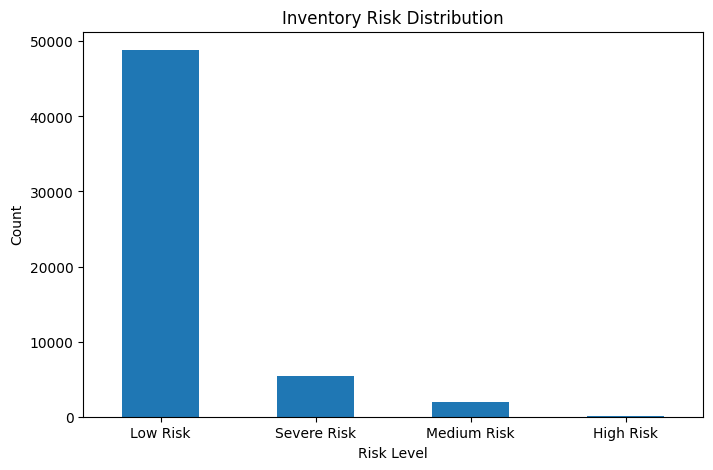

In [91]:
# Inventory Risk Distribution Chart
risk_counts = df['Inventory_Risk'].value_counts()

plt.figure(figsize=(8,5))

risk_counts.plot(kind='bar')

plt.title('Inventory Risk Distribution')

plt.xlabel('Risk Level')

plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

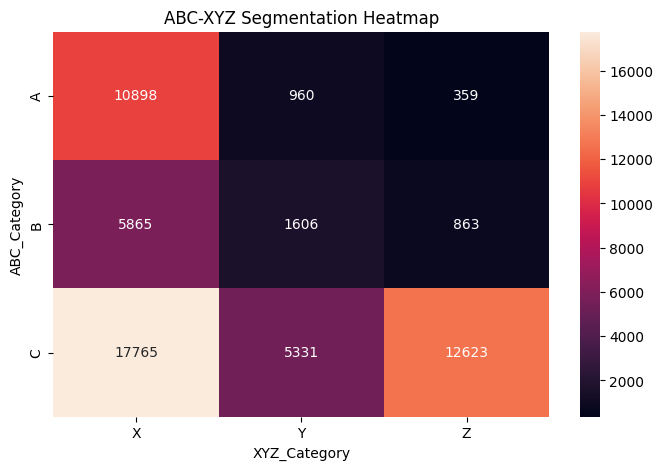

In [92]:
# ABC-XYZ Heatmap
abc_xyz_matrix = pd.crosstab(
    df['ABC_Category'],
    df['XYZ_Category']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    abc_xyz_matrix,
    annot=True,
    fmt='d'
)

plt.title('ABC-XYZ Segmentation Heatmap')

plt.show()

In [93]:
# Top Excess Inventory Chart
# NOTE: must run AFTER master_df is created (see section 7 below)
# Chart is reproduced there. This cell is kept as placeholder.
pass

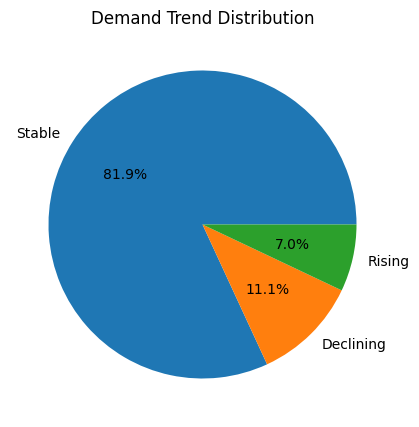

In [94]:
# Demand Trend Distribution
trend_counts = df['Demand_Trend'].value_counts()

plt.figure(figsize=(7,5))

trend_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Demand Trend Distribution')

plt.ylabel('')

plt.show()

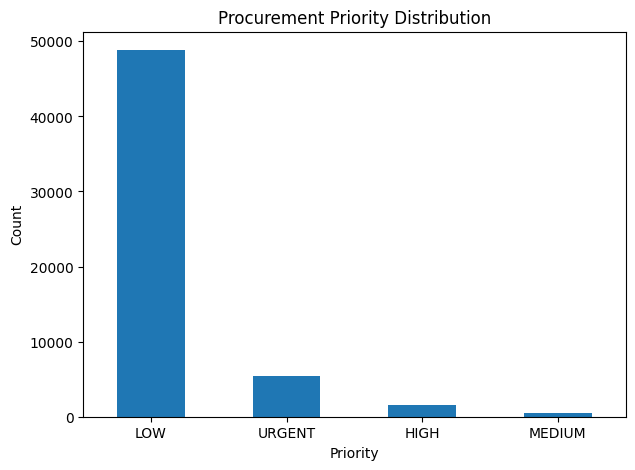

In [95]:
# Procurement Priority Chart
priority_counts = df[
    'Procurement_Priority'
].value_counts()

plt.figure(figsize=(7,5))

priority_counts.plot(kind='bar')

plt.title('Procurement Priority Distribution')

plt.xlabel('Priority')

plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

In [96]:
# NOTE: Avg_Daily_Demand / Days_To_Stockout / PO logic are computed on
# master_df (de-duplicated by material) in the section below.
# This keeps all PO fields consistent and avoids row-level duplication issues.

In [99]:
df['Last_Material'].duplicated().sum()

np.int64(14728)

In [100]:
# CREATE MASTER MATERIAL TABLE (one row per unique material)
master_df = df.groupby(
    'Last_Material',
    as_index=False
).agg({

    # Descriptive
    'Description':          'first',
    'ABC_XYZ':              'first',
    'ABC_Category':         'first',
    'XYZ_Category':         'first',
    'Demand_Trend':         'first',

    # Inventory
    'Net_Inventory':        'sum',

    # Demand
    'Annual_Demand':        'sum',
    'Avg_Monthly_Demand':   'mean',
    'Demand_StdDev':        'mean',

    # Lead Time
    'Effective_LT_Days':    'max',

    # Planning
    'ROP':                  'sum',
    'Safety_Stock':         'sum',

    # Financial
    'Net_Price':            'mean',

    # Risk & Flags
    'Inventory_Risk':       'first',
    'Reorder_Flag':         'first',
    'Dead_Stock_Flag':      'first',
    'Excess_Flag':          'first',
    'Procurement_Priority': 'first',
    'Recommended_Action':   'first',
})

print(f'master_df shape: {master_df.shape}')
print(f'Duplicate materials: {master_df["Last_Material"].duplicated().sum()}')

master_df shape: (41542, 20)
Duplicate materials: 0


In [101]:
# ── Financial Metrics on master_df ──────────────────────────────────────
master_df['Inventory_Value'] = master_df['Net_Inventory'] * master_df['Net_Price']

# Excess Qty: how much above ROP (ROP already includes Safety Stock)
master_df['Excess_Qty'] = master_df['Net_Inventory'] - master_df['ROP']

master_df['Excess_Value'] = np.where(
    master_df['Excess_Qty'] > 0,
    master_df['Excess_Qty'] * master_df['Net_Price'],
    0
)

master_df['Dead_Stock_Value'] = np.where(
    master_df['Dead_Stock_Flag'] == 'DEAD_STOCK',
    master_df['Inventory_Value'],
    0
)

master_df['Shortage_Exposure_Value'] = np.where(
    master_df['Inventory_Risk'] == 'Severe Risk',
    master_df['Net_Inventory'].abs() * master_df['Net_Price'],
    0
)

# ── PO / Stockout Fields on master_df ────────────────────────────────────
master_df['Avg_Daily_Demand'] = master_df['Avg_Monthly_Demand'] / 30

master_df['Days_To_Stockout'] = np.where(
    master_df['Avg_Daily_Demand'] > 0,
    master_df['Net_Inventory'] / master_df['Avg_Daily_Demand'],
    np.nan  # No demand → stockout not applicable
)

# PO Trigger Logic
def po_trigger(row):
    if pd.isnull(row['Days_To_Stockout']):
        return 'NO DEMAND'
    elif row['Days_To_Stockout'] <= row['Effective_LT_Days']:
        return 'TRIGGER PO'
    elif row['Days_To_Stockout'] <= (row['Effective_LT_Days'] + 15):
        return 'EXPEDITE'
    else:
        return 'MONITOR'

master_df['PO_Action'] = master_df.apply(po_trigger, axis=1)

# Recommended PO Quantity
master_df['Recommended_PO_Qty'] = np.where(
    master_df['ROP'] > master_df['Net_Inventory'],
    np.ceil(master_df['ROP'] - master_df['Net_Inventory']),
    0
)

# PO Alert
def po_alert(row):
    if row['PO_Action'] == 'TRIGGER PO':
        return 'URGENT BUY'
    elif row['PO_Action'] == 'EXPEDITE':
        return 'EXPEDITE SHIPMENT'
    else:
        return 'NORMAL'

master_df['PO_Alert'] = master_df.apply(po_alert, axis=1)

# PO Trigger Date (when to raise the PO)
from datetime import datetime, timedelta
today = datetime.today()

def calculate_trigger_date(days):
    if pd.isnull(days):
        return None
    days = min(days, 3650)          # cap at 10 years to avoid overflow
    trigger_days = max(days - 30, 0)  # raise PO 30 days before stockout
    return (today + timedelta(days=trigger_days)).date()

master_df['PO_Trigger_Date'] = master_df['Days_To_Stockout'].apply(calculate_trigger_date)

In [102]:
# PO Action summary
print('PO Action distribution:')
print(master_df['PO_Action'].value_counts())
print()
print('PO Alert distribution:')
print(master_df['PO_Alert'].value_counts())

PO Action distribution:
PO_Action
MONITOR       23836
NO DEMAND     16248
TRIGGER PO     1362
EXPEDITE         96
Name: count, dtype: int64

PO Alert distribution:
PO_Alert
NORMAL               40084
URGENT BUY            1362
EXPEDITE SHIPMENT       96
Name: count, dtype: int64


In [103]:
# ── URGENT PO LIST: Materials needing immediate purchase order ───────────
po_now = master_df[
    master_df['PO_Action'].isin(['TRIGGER PO', 'EXPEDITE'])
].sort_values(
    by=['PO_Action', 'Days_To_Stockout'],
    ascending=[True, True]
)[
    [
        'Last_Material', 'Description', 'ABC_XYZ',
        'Net_Inventory', 'ROP', 'Days_To_Stockout',
        'Effective_LT_Days', 'PO_Action', 'PO_Alert',
        'Recommended_PO_Qty', 'PO_Trigger_Date',
        'Procurement_Priority', 'Net_Price'
    ]
]

print(f'Materials requiring PO: {len(po_now)}')
po_now

Materials requiring PO: 1458


,Last_Material,Description,ABC_XYZ,Net_Inventory,ROP,Days_To_Stockout,Effective_LT_Days,PO_Action,PO_Alert,Recommended_PO_Qty,PO_Trigger_Date,Procurement_Priority,Net_Price
22119,453564113821,MS_X2 ASSY X2 Front Displ Eng Text w.SRR,AX,5.0,7.022299,21.852911,21.0,EXPEDITE,EXPEDITE SHIPMENT,3.0,2026-05-25,HIGH,408.32
38942,459801784941,"FRU, NVC HEAD TOP COVER - NID",BX,4.0,12.947435,28.203343,28.0,EXPEDITE,EXPEDITE SHIPMENT,9.0,2026-05-25,MEDIUM,90.31
40897,989606128511,HEMO WORKSTATION NETWORKED CI WITH OS,BY,2.0,3.283726,33.477991,30.0,EXPEDITE,EXPEDITE SHIPMENT,2.0,2026-05-29,MEDIUM,928.56
36847,459801275033,Module LED 130F,BX,4.0,4.187971,36.286258,28.0,EXPEDITE,EXPEDITE SHIPMENT,1.0,2026-06-01,MEDIUM,1364.94
1063,300005664101,Exch. Battery for SkyPlate single packed,AX,286.0,242.262026,37.103416,30.0,EXPEDITE,EXPEDITE SHIPMENT,0.0,2026-06-01,LOW,140.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32050,459800166652,I-Box-2 Base board assy,AX,238.0,308.042028,608.945606,725.0,TRIGGER PO,URGENT BUY,71.0,2027-12-25,HIGH,274.50
2291,300009316931,FRU SCCON-V5 (6335-2200-5400),CX,20.0,25.789227,609.480813,702.0,TRIGGER PO,URGENT BUY,6.0,2027-12-26,MEDIUM,5202.31
24563,453564950531,CHL-VS PCA Main board assy 863380-FS,AX,241.0,327.939993,625.132097,808.0,TRIGGER PO,URGENT BUY,87.0,2028-01-10,HIGH,156.43
38013,459801588062,Ceiling Suspension assembly FRU,CY,17.0,24.902943,677.657480,847.0,TRIGGER PO,URGENT BUY,8.0,2028-03-03,MEDIUM,8690.00


In [104]:
# ── KPI Summary ─────────────────────────────────────────────────────────
total_inventory   = master_df['Inventory_Value'].sum()
total_excess      = master_df['Excess_Value'].sum()
dead_stock        = master_df['Dead_Stock_Value'].sum()
shortage_exposure = master_df['Shortage_Exposure_Value'].sum()

print(f'Total Inventory Value   : {total_inventory:>15,.0f}')
print(f'Total Excess Value      : {total_excess:>15,.0f}')
print(f'Dead Stock Value        : {dead_stock:>15,.0f}')
print(f'Shortage Exposure Value : {shortage_exposure:>15,.0f}')

Total Inventory Value   :   6,080,317,691
Total Excess Value      :   2,263,480,275
Dead Stock Value        :      94,406,469
Shortage Exposure Value :               0


In [105]:
# ── Most Expensive Excess Materials ─────────────────────────────────────
master_df[[
    'Last_Material', 'Description', 'ABC_XYZ',
    'Inventory_Value', 'Excess_Value', 'Recommended_Action'
]].sort_values(by='Excess_Value', ascending=False).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
20662,453561921802,EPIQ B-Cart Acquisition Module,AX,7.847022e+08,1.595748e+08,Reduce Inventory
938,300004088644,ACE-e PCA with Fan assembly FRU,AX,2.334940e+08,1.555695e+08,Reduce Inventory
20417,453561842279,"Transducer, X8-2t",AY,2.259009e+08,1.281591e+08,Reduce Inventory
20992,453562021713,"Svc, EBOX Assy, HW E.X, ZUUL, KABY LAKE,",AY,2.898275e+08,1.186251e+08,Reduce Inventory
27857,453567560002,Spellman 80 KW RoHS CPM Assy,AX,1.163889e+08,8.792066e+07,Reduce Inventory
40125,989000086742,MRC 200+ 0407 ROT-GS 1004,AX,1.619649e+08,6.598370e+07,Reduce Inventory
21124,453562055185,"Transducer, X5-1c",AZ,9.900247e+07,5.309500e+07,Reduce Inventory
40101,989000085103,MRC 200 0407 ROT-GS 1004,AX,3.131240e+08,5.136965e+07,Reduce Inventory
20517,453561866752,EPIQ Acquisition Module,AX,2.952740e+08,5.088654e+07,Reduce Inventory
21163,453562060821,"ASSY, FRONT ACQUISITION w/CW, ITT, FRU",AY,9.208737e+07,4.878342e+07,Reduce Inventory


In [106]:
# ── Export Final Dataset ──────────────────────────────────────────────────
master_df.to_csv('master_inventory.csv', index=False)

print(f'Exported master_inventory.csv with {master_df.shape[0]} materials and {master_df.shape[1]} columns.')
print('\nColumns exported:')
print(list(master_df.columns))

Exported master_inventory.csv with 41542 materials and 31 columns.

Columns exported:
['Last_Material', 'Description', 'ABC_XYZ', 'ABC_Category', 'XYZ_Category', 'Demand_Trend', 'Net_Inventory', 'Annual_Demand', 'Avg_Monthly_Demand', 'Demand_StdDev', 'Effective_LT_Days', 'ROP', 'Safety_Stock', 'Net_Price', 'Inventory_Risk', 'Reorder_Flag', 'Dead_Stock_Flag', 'Excess_Flag', 'Procurement_Priority', 'Recommended_Action', 'Inventory_Value', 'Excess_Qty', 'Excess_Value', 'Dead_Stock_Value', 'Shortage_Exposure_Value', 'Avg_Daily_Demand', 'Days_To_Stockout', 'PO_Action', 'Recommended_PO_Qty', 'PO_Alert', 'PO_Trigger_Date']
